# Detection Eval & Warped Export (Edge-based)

Notebook chạy pipeline **Edge-based** trên test set có sẵn ground truth 4 góc:

1. Detect 4 góc tài liệu.
2. Tính metric cho **từng ảnh**: IoU, Dice, Corner Error.
3. In overlay vài ảnh để trực quan pipeline.
4. Warp ảnh gốc theo 4 góc detect được, lưu **ảnh warped + ma trận M** vào Drive để dùng tiếp cho OCR.

## Cách chạy

1. Chạy cell **Đọc dữ liệu từ kaggle** để tải dữ liệu từ kaggle.
2. Chạy lần lượt các cell còn lại.

## 1. Đọc data từ kaggle

In [ ]:
import os
from google.colab import files


!rm -rf ~/.cache/kaggle
!rm -rf /content/dataset

!kaggle datasets download -d tiendq/scanner --force
!unzip -q scanner.zip -d /content

In [ ]:
from pathlib import Path

IMAGE_DIR = Path('/content/dataset/test')
OUTPUT_DIR = Path('/content/label')

IMAGE_EXTS = ('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG')

IMAGE_EXTS = ('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG')

(OUTPUT_DIR / 'warped').mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / 'transforms').mkdir(parents=True, exist_ok=True)

print('IMAGE_DIR     =', IMAGE_DIR, ' exists =', IMAGE_DIR.exists())
print('ANNOTATION_DIR =', ANNOTATION_DIR, ' exists =', ANNOTATION_DIR.exists())
print('OUTPUT_DIR    =', OUTPUT_DIR)

## 2. Đọc data từ drive

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# from pathlib import Path

# # Thư mục ảnh test (trùng với cell config trong annotate_corners_colab.ipynb)
# IMAGE_DIR = Path('/content/drive/MyDrive/CV/pr/dataset/test')

# # Thư mục chứa các file <stem>.json (corners) đã annotate
# ANNOTATION_DIR = Path('/content/drive/MyDrive/CV/pr/dataset/test/label')

# # Nơi lưu kết quả: warped/, transforms/, results.csv
# OUTPUT_DIR = Path('/content/drive/MyDrive/CV/pr/dataset/test/eval_run')

# IMAGE_EXTS = ('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG')

# (OUTPUT_DIR / 'warped').mkdir(parents=True, exist_ok=True)
# (OUTPUT_DIR / 'transforms').mkdir(parents=True, exist_ok=True)

# print('IMAGE_DIR     =', IMAGE_DIR, ' exists =', IMAGE_DIR.exists())
# print('ANNOTATION_DIR =', ANNOTATION_DIR, ' exists =', ANNOTATION_DIR.exists())
# print('OUTPUT_DIR    =', OUTPUT_DIR)

IMAGE_DIR     = /content/drive/MyDrive/CV/pr/dataset/test/test_detection  exists = True
ANNOTATION_DIR = /content/drive/MyDrive/CV/pr/dataset/test/test_detection/label  exists = True
OUTPUT_DIR    = /content/drive/MyDrive/CV/pr/dataset/test/test_detection/eval_run


## 3. Imports

In [ ]:
import json
from dataclasses import dataclass
from typing import Any, Dict, List, Optional, Tuple

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

print('OpenCV', cv2.__version__, '| NumPy', np.__version__)

OpenCV 4.13.0 | NumPy 2.0.2


## 4. Edge-based detector


In [ ]:
# ── Helpers hình học ───────────────────────────────────────────────────────
def order_points(pts: np.ndarray) -> np.ndarray:
    pts = np.asarray(pts, dtype=np.float32).reshape(4, 2)
    center = pts.mean(axis=0)
    angles = np.arctan2(pts[:, 1] - center[1], pts[:, 0] - center[0])
    rect = pts[np.argsort(angles)].astype(np.float32)
    rect = np.roll(rect, -int(np.argmin(rect.sum(axis=1))), axis=0)
    if rect[1, 0] < rect[3, 0]:
        rect[[1, 3]] = rect[[3, 1]]
    return rect.astype(np.float32)


def quad_features(quad: np.ndarray, image_shape: Tuple[int, int]) -> Dict[str, float]:
    h, w = image_shape[:2]
    rect = order_points(quad)
    tl, tr, br, bl = rect
    width = max(np.linalg.norm(tr - tl), np.linalg.norm(br - bl), 1.0)
    height = max(np.linalg.norm(bl - tl), np.linalg.norm(br - tr), 1.0)
    area = float(abs(cv2.contourArea(rect.reshape(-1, 1, 2))))
    angles = []
    for i in range(4):
        a, b, c = rect[(i - 1) % 4], rect[i], rect[(i + 1) % 4]
        v1, v2 = a - b, c - b
        d = float(np.linalg.norm(v1) * np.linalg.norm(v2))
        if d <= 1e-6:
            angles.append(0.0); continue
        angles.append(float(np.degrees(np.arccos(np.clip(np.dot(v1, v2) / d, -1, 1)))))
    return {
        'area_ratio': area / (h * w),
        'aspect_ratio': float(width / height),
        'fill_ratio': float(area / max(width * height, 1.0)),
        'min_angle': float(min(angles)) if angles else 0.0,
        'max_angle': float(max(angles)) if angles else 180.0,
        'angle_spread': float(max(angles) - min(angles)) if angles else 180.0,
    }


def validate_quad(quad: Optional[np.ndarray], image_shape: Tuple[int, int]) -> bool:
    if quad is None:
        return False
    quad = np.asarray(quad, dtype=np.float32).reshape(-1, 2)
    if len(quad) != 4:
        return False
    rect = order_points(quad)
    if not cv2.isContourConvex(rect.reshape(4, 1, 2).astype(np.float32)):
        return False
    f = quad_features(rect, image_shape)
    if not (0.05 <= f['area_ratio'] <= 0.95):
        return False
    if not (0.25 <= f['aspect_ratio'] <= 4.0):
        return False
    if f['min_angle'] < 35.0 or f['max_angle'] > 145.0:
        return False
    return True


def score_quad(quad: np.ndarray, image_shape: Tuple[int, int]) -> float:
    f = quad_features(quad, image_shape)
    area_score = min(f['area_ratio'] / 0.65, 1.0)
    fill_score = float(np.clip(f['fill_ratio'], 0.0, 1.0))
    aspect_score = 1.0 if 0.5 <= f['aspect_ratio'] <= 2.5 else 0.7
    angle_score = 1.0 - float(np.clip(f['angle_spread'] / 90.0, 0.0, 1.0))
    rect = order_points(quad)
    h, w = image_shape[:2]
    mx, my = 0.015 * w, 0.015 * h
    touches = (rect[:, 0].min() <= mx or rect[:, 1].min() <= my or
               rect[:, 0].max() >= w - mx or rect[:, 1].max() >= h - my)
    return float(0.45 * area_score + 0.20 * fill_score + 0.15 * aspect_score +
                 0.15 * angle_score - (0.15 if touches else 0.0))


def contour_to_quad(contour: np.ndarray, image_shape: Tuple[int, int]) -> Optional[np.ndarray]:
    if cv2.contourArea(contour) <= 0:
        return None
    hull = cv2.convexHull(contour)
    perim = cv2.arcLength(hull, True)
    if perim <= 0:
        return None
    best: Optional[Tuple[float, np.ndarray]] = None
    for eps in (0.02, 0.03, 0.04, 0.05, 0.06):
        approx = cv2.approxPolyDP(hull, eps * perim, True)
        if len(approx) == 4 and cv2.isContourConvex(approx):
            quad = order_points(approx.reshape(4, 2))
            if validate_quad(quad, image_shape):
                s = score_quad(quad, image_shape) + 0.01 * (1.0 - eps)
                if best is None or s > best[0]:
                    best = (s, quad)
    if best is not None:
        return best[1]
    # fallback: minAreaRect
    rect = cv2.minAreaRect(contour)
    quad = order_points(cv2.boxPoints(rect))
    box_area = float(abs(cv2.contourArea(quad.reshape(-1, 1, 2))))
    if cv2.contourArea(contour) / max(box_area, 1.0) < 0.65:
        return None
    return quad if validate_quad(quad, image_shape) else None


print('Quad helpers OK')

Quad helpers OK


In [ ]:
@dataclass
class EdgeConfig:
    target_long_side: int = 1000
    blur_ksize: int = 5
    clahe_clip: float = 2.0
    clahe_tile: Tuple[int, int] = (8, 8)
    canny_sigma: float = 0.33
    morph_ksize: int = 5
    dilate_iter: int = 2
    close_iter: int = 1
    top_k_contours: int = 10
    min_area_ratio: float = 0.05
    score_accept: float = 0.40


def detect_corners(img_bgr: np.ndarray, cfg: EdgeConfig = EdgeConfig()) -> Dict[str, Any]:
    H, W = img_bgr.shape[:2]
    scale = cfg.target_long_side / max(H, W)
    if scale >= 1.0:
        resized, scale = img_bgr, 1.0
    else:
        resized = cv2.resize(img_bgr, (int(W * scale), int(H * scale)),
                             interpolation=cv2.INTER_AREA)
    L = cv2.cvtColor(resized, cv2.COLOR_BGR2LAB)[:, :, 0]
    L = cv2.createCLAHE(cfg.clahe_clip, cfg.clahe_tile).apply(L)
    blurred = cv2.GaussianBlur(L, (cfg.blur_ksize | 1,) * 2, 0)

    v = float(np.median(blurred))
    lo = int(max(0, (1 - cfg.canny_sigma) * v))
    hi = int(min(255, (1 + cfg.canny_sigma) * v))
    edges = cv2.Canny(blurred, lo, hi)
    k = max(3, cfg.morph_ksize | 1)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (k, k))
    proc = cv2.dilate(edges, kernel, iterations=cfg.dilate_iter)
    proc = cv2.morphologyEx(proc, cv2.MORPH_CLOSE, kernel, iterations=cfg.close_iter)

    contours, _ = cv2.findContours(proc, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)[:cfg.top_k_contours]
    img_area = float(blurred.shape[0] * blurred.shape[1])

    best_quad, best_score = None, 0.0
    for cnt in contours:
        if cv2.contourArea(cnt) < img_area * cfg.min_area_ratio:
            continue
        quad = contour_to_quad(cnt, blurred.shape)
        if quad is None:
            continue
        s = score_quad(quad, blurred.shape)
        if s > best_score:
            best_quad, best_score = quad, s

    corners_orig = None
    if best_quad is not None:
        corners_orig = best_quad / scale
        corners_orig[:, 0] = np.clip(corners_orig[:, 0], 0, W - 1)
        corners_orig[:, 1] = np.clip(corners_orig[:, 1], 0, H - 1)
        corners_orig = order_points(corners_orig)

    return {
        'corners': corners_orig, 'score': best_score,
        'success': corners_orig is not None and best_score >= cfg.score_accept,
        'edges': edges, 'edges_processed': proc, 'resized': resized,
    }


print('detect_corners() OK')

detect_corners() OK


## 5. Warp + metric helpers

In [ ]:
def warp_with_M(img: np.ndarray, corners: np.ndarray) -> Dict[str, Any]:
    rect = order_points(corners)
    tl, tr, br, bl = rect
    W = max(int(round(max(np.linalg.norm(br - bl), np.linalg.norm(tr - tl)))), 2)
    H = max(int(round(max(np.linalg.norm(tr - br), np.linalg.norm(tl - bl)))), 2)
    dst = np.array([[0, 0], [W - 1, 0], [W - 1, H - 1], [0, H - 1]], dtype=np.float32)
    M = cv2.getPerspectiveTransform(rect, dst)
    warped = cv2.warpPerspective(img, M, (W, H), flags=cv2.INTER_CUBIC)
    return {'warped': warped, 'M': M, 'warped_size': (W, H)}


def quad_to_mask(quad: np.ndarray, shape: Tuple[int, int]) -> np.ndarray:
    m = np.zeros(shape[:2], dtype=np.uint8)
    cv2.fillPoly(m, [np.asarray(quad, np.int32)], 255)
    return m


def compute_metrics(pred: Optional[np.ndarray], gt: Optional[np.ndarray],
                    shape: Tuple[int, int]) -> Dict[str, Optional[float]]:
    if pred is None or gt is None:
        return {'iou': None, 'dice': None, 'corner_err_px': None, 'corner_err_norm': None}
    H, W = shape[:2]
    mp = quad_to_mask(pred, shape) > 0
    mg = quad_to_mask(gt, shape) > 0
    inter = float(np.logical_and(mp, mg).sum())
    union = float(np.logical_or(mp, mg).sum())
    iou = inter / max(union, 1.0)
    dice = 2 * inter / max(float(mp.sum() + mg.sum()), 1.0)
    P = order_points(np.asarray(pred, np.float32))
    G = order_points(np.asarray(gt, np.float32))
    ce = float(np.linalg.norm(P - G, axis=1).mean())
    return {'iou': iou, 'dice': dice,
            'corner_err_px': ce,
            'corner_err_norm': ce / float(np.hypot(H, W))}


print('warp + metric helpers OK')

warp + metric helpers OK


## 6. Chạy pipeline trên test set

In [ ]:
def list_images(image_dir: Path, exts=IMAGE_EXTS) -> List[Path]:
    files = []
    for ext in exts:
        files.extend(image_dir.glob(f'*{ext}'))
    seen, out = set(), []
    for f in sorted(files):
        if f.name not in seen:
            seen.add(f.name); out.append(f)
    return out


image_paths = list_images(IMAGE_DIR)
matched: List[Tuple[Path, Path]] = []
missing_gt: List[str] = []
for p in image_paths:
    j = ANNOTATION_DIR / f'{p.stem}.json'
    if j.exists():
        matched.append((p, j))
    else:
        missing_gt.append(p.name)

print(f'Tổng ảnh trong IMAGE_DIR : {len(image_paths)}')
print(f'Có annotation            : {len(matched)}')
if missing_gt:
    print(f'Thiếu annotation ({len(missing_gt)}): {missing_gt[:10]}{"..." if len(missing_gt) > 10 else ""}')
if not matched:
    raise RuntimeError('Không có cặp ảnh-annotation nào để chạy.')

Tổng ảnh trong IMAGE_DIR : 25
Có annotation            : 25


In [ ]:
def load_gt_corners(json_path: Path) -> Optional[np.ndarray]:
    with open(json_path, encoding='utf-8') as f:
        ann = json.load(f)
    if not ann.get('has_document', True):
        return None
    pts = ann.get('corners')
    if not pts or len(pts) != 4:
        return None
    return order_points(np.asarray(pts, dtype=np.float32))


rows: List[Dict[str, Any]] = []

for img_path, ann_path in tqdm(matched, desc='Detect + eval'):
    img = cv2.imread(str(img_path))
    if img is None:
        rows.append({'image': img_path.name, 'detected': False, 'note': 'cannot read image'})
        continue

    H, W = img.shape[:2]
    gt = load_gt_corners(ann_path)

    det = detect_corners(img)
    pred = det['corners']
    metrics = compute_metrics(pred, gt, (H, W))

    warped_path = ''
    transform_path = ''
    warped_size = (0, 0)

    if pred is not None:
        wr = warp_with_M(img, pred)
        warped_size = wr['warped_size']

        wpath = OUTPUT_DIR / 'warped' / f'{img_path.stem}.jpg'
        cv2.imwrite(str(wpath), wr['warped'], [cv2.IMWRITE_JPEG_QUALITY, 95])
        warped_path = str(wpath)

        tpath = OUTPUT_DIR / 'transforms' / f'{img_path.stem}.json'
        with open(tpath, 'w', encoding='utf-8') as f:
            json.dump({
                'image_name': img_path.name,
                'original_size': [int(W), int(H)],
                'warped_size':   [int(warped_size[0]), int(warped_size[1])],
                'M':             wr['M'].tolist(),
                'corners_pred':  pred.tolist(),
                'corners_gt':    None if gt is None else gt.tolist(),
                'metrics':       {k: (None if v is None else float(v)) for k, v in metrics.items()},
            }, f, indent=2, ensure_ascii=False)
        transform_path = str(tpath)

    rows.append({
        'image':           img_path.name,
        'orig_w':          W,
        'orig_h':          H,
        'warp_w':          warped_size[0],
        'warp_h':          warped_size[1],
        'detected':        pred is not None,
        'score':           round(float(det['score']), 4),
        'iou':             None if metrics['iou']  is None else round(metrics['iou'],  4),
        'dice':            None if metrics['dice'] is None else round(metrics['dice'], 4),
        'corner_err_px':   None if metrics['corner_err_px']   is None else round(metrics['corner_err_px'],   2),
        'corner_err_norm': None if metrics['corner_err_norm'] is None else round(metrics['corner_err_norm'], 4),
        'warped_path':     warped_path,
        'transform_path':  transform_path,
    })

results_df = pd.DataFrame(rows)
results_csv = OUTPUT_DIR / 'results.csv'
results_df.to_csv(results_csv, index=False)
print(f'\nLưu metric → {results_csv}')
results_df

Detect + eval: 100%|██████████| 25/25 [00:15<00:00,  1.57it/s]


Lưu metric → /content/drive/MyDrive/CV/pr/dataset/test/test_detection/eval_run/results.csv


,image,orig_w,orig_h,warp_w,warp_h,detected,score,iou,dice,corner_err_px,corner_err_norm,warped_path,transform_path
0,2aOboQY0L8fcafZOXWcTbRm76XS8xGc87Tpt8AcK.jpg,1920,2560,1654,1928,True,0.7172,0.8624,0.9261,109.11,0.0341,/content/drive/MyDrive/CV/pr/dataset/test/test...,/content/drive/MyDrive/CV/pr/dataset/test/test...
1,2aOboQY0L9onL7d3cC90sscKr1DKODoFvOjUCfnU.jpg,1920,2560,1101,1080,True,0.5993,0.4337,0.6050,411.55,0.1286,/content/drive/MyDrive/CV/pr/dataset/test/test...,/content/drive/MyDrive/CV/pr/dataset/test/test...
2,2aOboQY0LACxpFeZg6YgsVdZzeiLWIpuUxHJ7qdc.jpg,1920,2560,1026,1030,True,0.4848,0.2767,0.4335,640.96,0.2003,/content/drive/MyDrive/CV/pr/dataset/test/test...,/content/drive/MyDrive/CV/pr/dataset/test/test...
3,2aOboQY0LAJn6DUXGEdvl9wvZzPy7e1ckp5uEkjo.jpg,1920,2560,1917,1938,True,0.7926,0.7414,0.8515,227.04,0.0710,/content/drive/MyDrive/CV/pr/dataset/test/test...,/content/drive/MyDrive/CV/pr/dataset/test/test...
4,2aOboQY0LBwLs4o8LQpYJ31H0OSflP7tBBHsTLTE.jpg,1920,2560,1856,2115,True,0.7596,0.8827,0.9377,94.62,0.0296,/content/drive/MyDrive/CV/pr/dataset/test/test...,/content/drive/MyDrive/CV/pr/dataset/test/test...
5,2aOboQY0LC73yNrcl7Rhl4OeHk2qDyFn2R3Lmb0y.jpg,1920,2560,1839,2075,True,0.7926,0.7783,0.8753,181.73,0.0568,/content/drive/MyDrive/CV/pr/dataset/test/test...,/content/drive/MyDrive/CV/pr/dataset/test/test...
6,2aOboQY0LCLhKr51VZSxcnN0NlDHNyBOZlwpWIAS.jpg,1920,2560,1907,2153,True,0.7490,0.7985,0.8879,174.99,0.0547,/content/drive/MyDrive/CV/pr/dataset/test/test...,/content/drive/MyDrive/CV/pr/dataset/test/test...
7,2aOboQY0LCyr4qnLqnlc5BV3WBOvcFJOiii2I2zY.jpg,1920,2560,1834,2156,True,0.7841,0.7839,0.8789,187.51,0.0586,/content/drive/MyDrive/CV/pr/dataset/test/test...,/content/drive/MyDrive/CV/pr/dataset/test/test...
8,2aOboQY0LD3AfEN3DducwGDzfbjAeH5WaCcjBvxQ.jpg,1920,2560,1877,2189,True,0.7866,0.7960,0.8864,180.86,0.0565,/content/drive/MyDrive/CV/pr/dataset/test/test...,/content/drive/MyDrive/CV/pr/dataset/test/test...
9,2aOboQY0LDAJOlk2pQzOZbYRrjRjcGF3huCPCQ1g.jpg,1920,2560,1772,2249,True,0.7477,0.8051,0.8920,172.26,0.0538,/content/drive/MyDrive/CV/pr/dataset/test/test...,/content/drive/MyDrive/CV/pr/dataset/test/test...


## 7. Tổng hợp metric

In [ ]:
df = results_df.copy()
n_total = len(df)
n_detected = int(df['detected'].sum())
n_with_iou = int(df['iou'].notna().sum())

print(f'Tổng ảnh           : {n_total}')
print(f'Detect được        : {n_detected} ({n_detected / max(n_total,1):.1%})')
print(f'Có cả pred + GT    : {n_with_iou}')
if n_with_iou:
    print(f'Mean IoU           : {df["iou"].mean(skipna=True):.4f}')
    print(f'Median IoU         : {df["iou"].median(skipna=True):.4f}')
    print(f'Mean Dice          : {df["dice"].mean(skipna=True):.4f}')
    print(f'Mean Corner Err px : {df["corner_err_px"].mean(skipna=True):.2f}')
    for thr in (0.5, 0.7, 0.85):
        passed = int((df['iou'] >= thr).sum())
        print(f'  IoU ≥ {thr:.2f}        : {passed}/{n_with_iou} ({passed/max(n_with_iou,1):.1%})')

Tổng ảnh           : 25
Detect được        : 24 (96.0%)
Có cả pred + GT    : 24
Mean IoU           : 0.7511
Median IoU         : 0.7900
Mean Dice          : 0.8431
Mean Corner Err px : 172.49
  IoU ≥ 0.50        : 21/24 (87.5%)
  IoU ≥ 0.70        : 18/24 (75.0%)
  IoU ≥ 0.85        : 8/24 (33.3%)


## 8. Trực quan vài ảnh

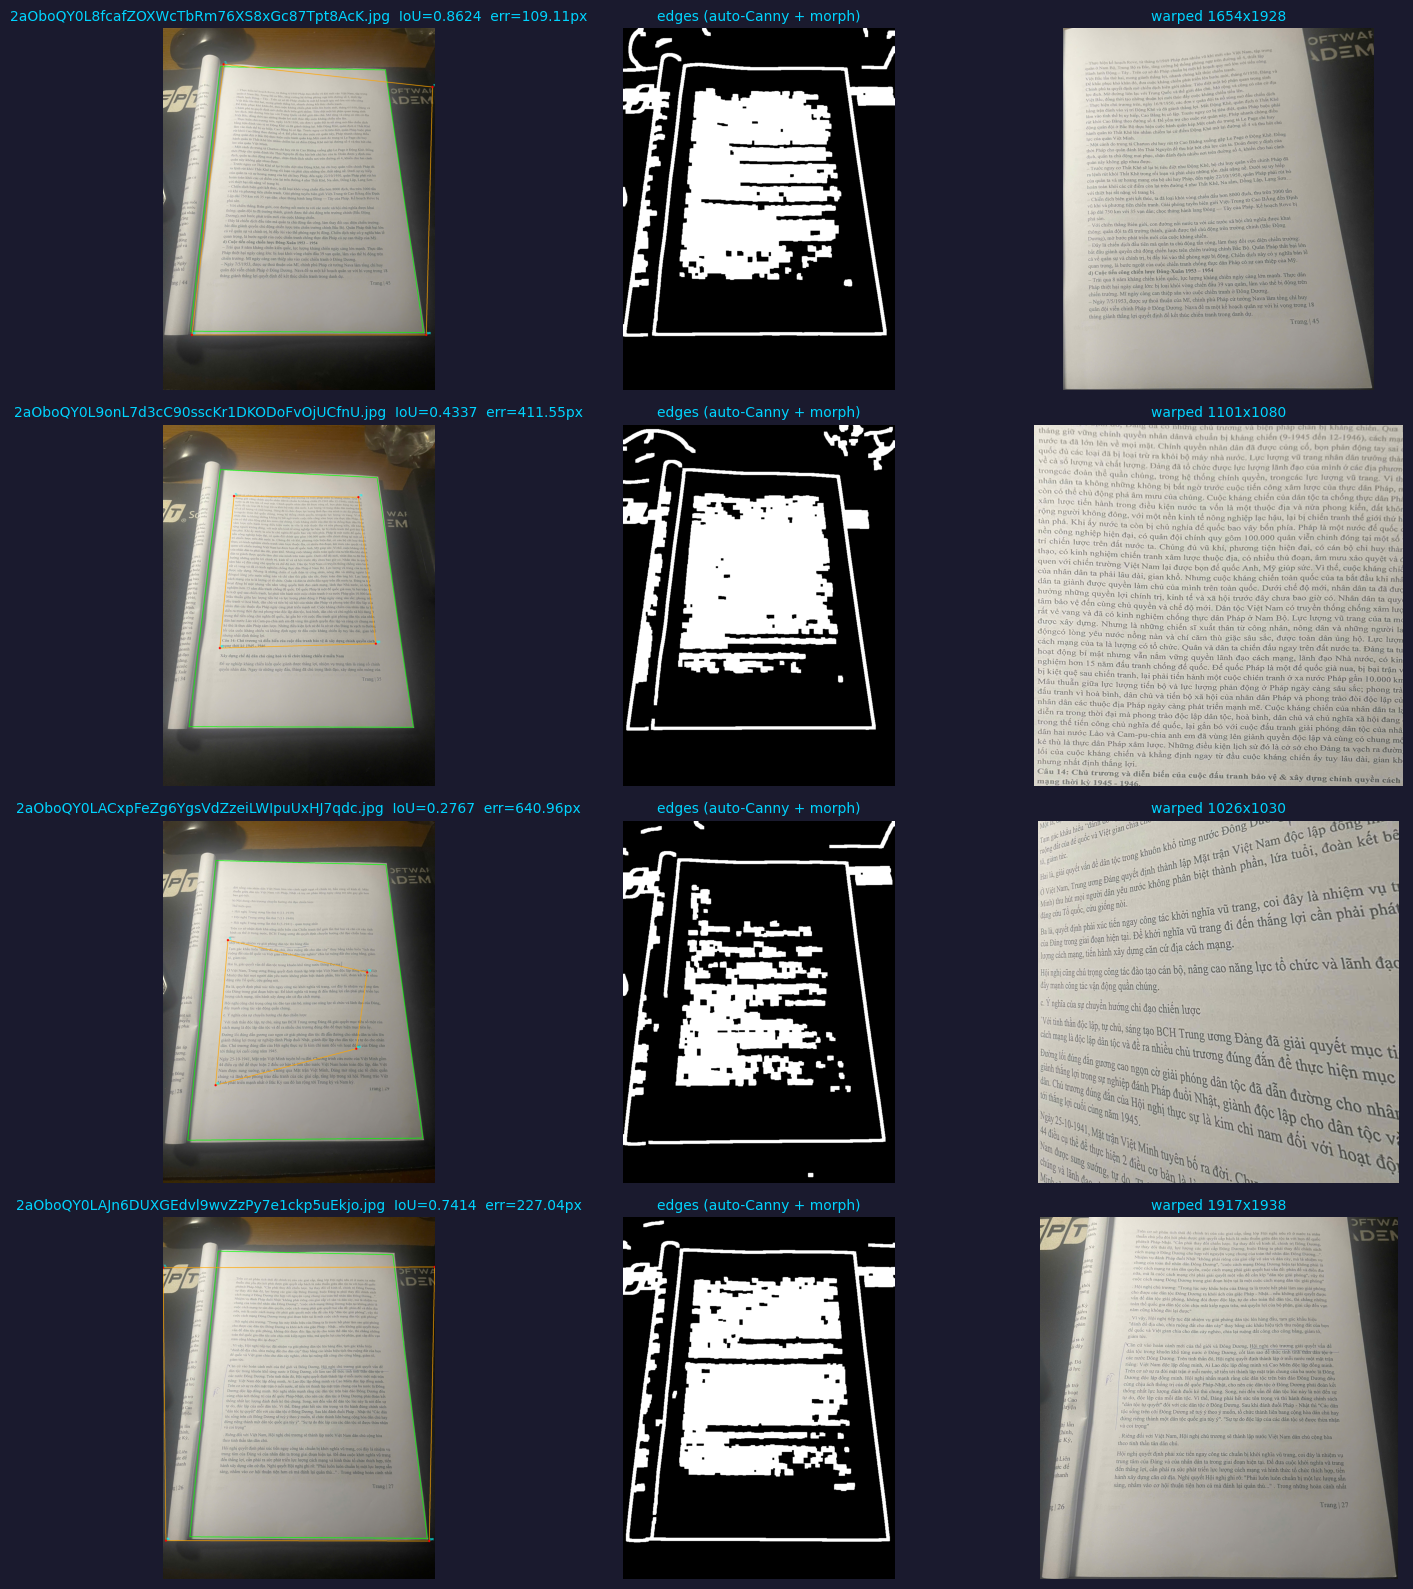

In [ ]:
n_show = 4
show_rows = df.head(n_show).to_dict('records')

fig, axes = plt.subplots(len(show_rows), 3, figsize=(15, 4 * len(show_rows)))
if len(show_rows) == 1:
    axes = np.array([axes])

for i, row in enumerate(show_rows):
    img_path = IMAGE_DIR / row['image']
    img = cv2.imread(str(img_path))
    if img is None:
        for ax in axes[i]:
            ax.axis('off')
        continue

    gt = load_gt_corners(ANNOTATION_DIR / f'{img_path.stem}.json')
    det = detect_corners(img)
    pred = det['corners']

    # 1) overlay GT (xanh) + Pred (cam) trên ảnh gốc
    overlay = img.copy()
    if gt is not None:
        cv2.polylines(overlay, [np.asarray(gt, np.int32)], True, (0, 255, 0), 4)
    if pred is not None:
        cv2.polylines(overlay, [np.asarray(pred, np.int32)], True, (0, 165, 255), 3)
        for j, p in enumerate(np.asarray(pred, np.int32)):
            cv2.circle(overlay, tuple(p), 8, (0, 0, 255), -1)
            cv2.putText(overlay, ['TL', 'TR', 'BR', 'BL'][j], tuple(p + np.array([6, -6])),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 0), 2)
    axes[i, 0].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    title = f"{row['image']}  IoU={row['iou']}  err={row['corner_err_px']}px"
    axes[i, 0].set_title(title, fontsize=10); axes[i, 0].axis('off')

    # 2) edges_processed
    axes[i, 1].imshow(det['edges_processed'], cmap='gray')
    axes[i, 1].set_title('edges (auto-Canny + morph)', fontsize=10)
    axes[i, 1].axis('off')

    # 3) warped
    if pred is not None:
        wr = warp_with_M(img, pred)
        axes[i, 2].imshow(cv2.cvtColor(wr['warped'], cv2.COLOR_BGR2RGB))
        axes[i, 2].set_title(f"warped {wr['warped_size'][0]}x{wr['warped_size'][1]}", fontsize=10)
    else:
        axes[i, 2].text(0.5, 0.5, 'no quad', ha='center', va='center')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()